In [201]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt

In [202]:
def generate_credit_data(n_samples=1000, n_features=10, random_state=42):
    X, y = make_classification(
        n_samples=n_samples, n_features=n_features,
        n_informative=6, n_redundant=2, n_clusters_per_class=2,
        random_state=random_state
    )
    return X, y

X, y = generate_credit_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

A) Niestabilność i Wizualizacja

In [203]:
def train_single_trees(X, y, n_trees=10):
    trees = []
    for i in range(n_trees):
        tree = DecisionTreeClassifier(random_state=i)
        tree.fit(X, y)
        trees.append(tree)
    return trees

Średnia wariancja (Pojedyncze Drzewo): 0.02415


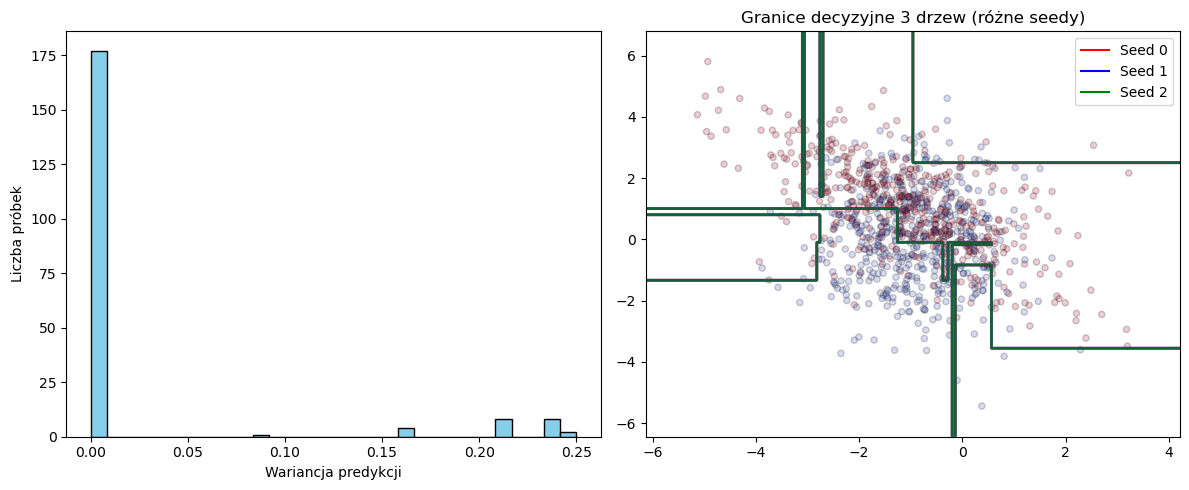

Średnia dokładność (Pojedyncze Drzewo): 0.81850


In [204]:
single_trees = train_single_trees(X_train, y_train, n_trees=10)

all_probs = []
for tree in single_trees:
    all_probs.append(tree.predict_proba(X_test)[:, 1])
all_probs = np.array(all_probs) # (10, n_test_samples)

variances = np.var(all_probs, axis=0)
mean_variance_single = np.mean(variances)
print(f"Średnia wariancja (Pojedyncze Drzewo): {mean_variance_single:.5f}")

# Histogram Wariancji
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(variances, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Wariancja predykcji")
plt.ylabel("Liczba próbek")

# Granice Decyzyjne (na 2 cechach)
plt.subplot(1, 2, 2)
# Musimy wytrenować nowe drzewa tylko na 2 cechach, żeby to narysować w 2D
X_viz = X[:, :2] 
h = 0.02
x_min, x_max = X_viz[:, 0].min() - 1, X_viz[:, 0].max() + 1
y_min, y_max = X_viz[:, 1].min() - 1, X_viz[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

colors = ['red', 'blue', 'green']
labels = ['Seed 0', 'Seed 1', 'Seed 2']

for i in range(3):
    clf = DecisionTreeClassifier(random_state=i, max_depth=5)
    clf.fit(X_viz, y)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    # Rysujemy tylko granicę (contour)
    plt.contour(xx, yy, Z, colors=[colors[i]], levels=[0.5], linewidths=2, alpha=0.7)
    plt.plot([], [], color=colors[i], label=labels[i])

plt.scatter(X_viz[:, 0], X_viz[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm, s=20, alpha=0.2)
plt.title("Granice decyzyjne 3 drzew (różne seedy)")
plt.legend()
plt.tight_layout()
plt.show()

accs = []
for tree in single_trees:
    accs.append(tree.score(X_test, y_test))
mean_acc_single = np.mean(accs)

print(f"Średnia dokładność (Pojedyncze Drzewo): {mean_acc_single:.5f}")

B) Bagging i Redukcja Wariancji

In [205]:
def bootstrap_sample(X, y, random_state=None):
    rng = np.random.RandomState(random_state)
    n = len(X)
    indices = rng.choice(n, size=n, replace=True)
    oob_indices = list(set(range(n)) - set(indices))
    return X[indices], y[indices], oob_indices

In [206]:
def ensemble_predict(trees, X):
    preds = np.array([tree.predict(X) for tree in trees])
    mean_preds = np.mean(preds, axis=0)
    return (mean_preds > 0.5).astype(int)

In [207]:
def train_bagging(X, y, n_trees=50, use_random_features=False):
    trees = []
    oob_indices_list = []
    for i in range(n_trees):
        X_boot, y_boot, oob_idx = bootstrap_sample(X, y, random_state=i)
        
        if use_random_features:
            # Punkt C: max_features='sqrt'
            tree = DecisionTreeClassifier(max_features='sqrt', random_state=i)
        else:
            # Punkt B: Zwykłe drzewo
            tree = DecisionTreeClassifier(random_state=i)
            
        tree.fit(X_boot, y_boot)
        trees.append(tree)
        oob_indices_list.append(oob_idx)
    return trees, oob_indices_list

In [208]:
bagging_trees, _ = train_bagging(X_train, y_train, n_trees=50)

forest_preds = []
rng = np.random.RandomState(2137)
for i in range(10):
    # Generujemy 10 lasów, każdy ma nieco inne seedy bootstrapu
    seed_offset = i * 1000
    trees_temp = []
    for k in range(50):
        X_b, y_b, _ = bootstrap_sample(X_train, y_train, random_state=seed_offset + k)
        t = DecisionTreeClassifier(random_state=seed_offset + k)
        t.fit(X_b, y_b)
        trees_temp.append(t)
    
    # Średnia predykcja lasu
    p = np.mean([t.predict_proba(X_test)[:, 1] for t in trees_temp], axis=0)
    forest_preds.append(p)

variance_bagging = np.var(forest_preds, axis=0)
mean_var_bagging = np.mean(variance_bagging)

print(f"Średnia wariancja (10 Lasów Bagging): {mean_var_bagging:.5f}")
drop = 100 * (1 - mean_var_bagging/mean_variance_single)
print(f"Spadek wariancji o: {drop:.1f}%")

Średnia wariancja (10 Lasów Bagging): 0.00175
Spadek wariancji o: 92.8%


c) Random Forest i Korelacja

In [209]:
def build_randomized_tree(X, y, random_state=None):
    """Tworzy drzewo decyzyjne z losowaniem cech (max_features='sqrt')."""
    clf = DecisionTreeClassifier(
        max_features='sqrt',  
        random_state=random_state
    )
    # max_features : int, float or {"sqrt", "log2"}, default=None
    #     The number of features to consider when looking for the best split:
    clf.fit(X, y)
    return clf

def train_random_forest(X, y, n_trees=50):
    trees = []
    oob_indices_list = []
    
    for i in range(n_trees):
        X_boot, y_boot, oob_idx = bootstrap_sample(X, y, random_state=i)
        
        tree = build_randomized_tree(X_boot, y_boot, random_state=i)
        
        trees.append(tree)
        oob_indices_list.append(oob_idx)
        
    return trees, oob_indices_list

rf_trees, rf_oob_indices = train_random_forest(X_train, y_train, n_trees=50)


def calculate_average_correlation(trees, X):
    preds = np.array([t.predict_proba(X)[:, 1] for t in trees]).T 
    corr_matrix = np.corrcoef(preds, rowvar=False) 
    upper_tri_indices = np.triu_indices_from(corr_matrix, k=1) # k to offset of diag
    return np.mean(corr_matrix[upper_tri_indices])

corr_bagging = calculate_average_correlation(bagging_trees, X_test)
corr_rf = calculate_average_correlation(rf_trees, X_test)

print(f"Średnia korelacja drzew (Bagging):       {corr_bagging:.4f}")
print(f"Średnia korelacja drzew (Random Forest): {corr_rf:.4f}")

Średnia korelacja drzew (Bagging):       0.6089
Średnia korelacja drzew (Random Forest): 0.5374


Drzewa w Random Forest są mniej skorelowane (bardziej różnorodne).

Drzewa patrzą na mniejszy (losowy) zakres ficzerów, co "sprawia, że różnorodniej dzieli, a nie zawsze ten najlepszy, którey może suktować większą korelacją, ... bo powtażalny

d) Nasycenie i OOB Error

Asymptotycznie (1/e) ~ 36% danyych nie zostanie wylsowancyh metoda bootstrap z punktu b. Wykorzystujemy te dane jako zbiór validacyny

dla ustalonej 1 z n danych z pstwem (1 - 1/n)^n nie wylosujemy jej boostrapując, dlatego że losujemy n razy ze zwracaniem

In [ ]:
def calculate_oob_error(X, y, trees, oob_indices_list):
    n_samples = len(X)
    votes = np.zeros((n_samples, 2))
    counts = np.zeros(n_samples)
    
    for i, tree in enumerate(trees):
        oob_idx = oob_indices_list[i]
        if len(oob_idx) == 0: continue
        
        preds = tree.predict(X[oob_idx])
        for sample_idx, pred_val in zip(oob_idx, preds):
            votes[sample_idx, int(pred_val)] += 1
            counts[sample_idx] += 1
            
    mask = counts > 0
    final_preds = np.argmax(votes[mask], axis=1)
    return 1.0 - np.mean(final_preds == y[mask])

In [212]:
n_options = [10, 50, 100, 200, 500]
oob_errors = []
test_errors = []

for n in n_options:
    # Trenujemy RF
    trees, oob_idx = train_bagging(X_train, y_train, n_trees=n, use_random_features=True)
    
    # OOB
    oob_e = calculate_oob_error(X_train, y_train, trees, oob_idx)
    oob_errors.append(oob_e)
    
    # Test
    test_pred = ensemble_predict(trees, X_test)
    test_e = 1.0 - np.mean(test_pred == y_test)
    test_errors.append(test_e)
    
    print(f"Drzew: {n:3d} | OOB: {oob_e:.4f} | Test: {test_e:.4f}")

Drzew:  10 | OOB: 0.1430 | Test: 0.1650
Drzew:  50 | OOB: 0.1062 | Test: 0.1650
Drzew: 100 | OOB: 0.0863 | Test: 0.1600
Drzew: 200 | OOB: 0.0813 | Test: 0.1600
Drzew: 500 | OOB: 0.0875 | Test: 0.1500


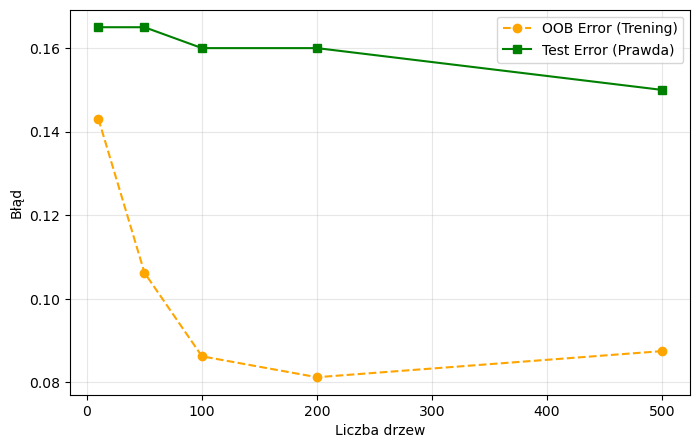


Sklearn RF Accuracy: 0.8550
Nasz RF Accuracy:    0.8500


In [213]:
# Wykres Nasycenia
plt.figure(figsize=(8, 5))
plt.plot(n_options, oob_errors, 'o--', label='OOB Error (Trening)', color='orange')
plt.plot(n_options, test_errors, 's-', label='Test Error (Prawda)', color='green')
plt.xlabel("Liczba drzew")
plt.ylabel("Błąd")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Porównanie ze Sklearn
rf_sk = RandomForestClassifier(n_estimators=500, max_features='sqrt', random_state=42)
rf_sk.fit(X_train, y_train)
sk_acc = rf_sk.score(X_test, y_test)
print(f"\nSklearn RF Accuracy: {sk_acc:.4f}")
print(f"Nasz RF Accuracy:    {1.0 - test_errors[-1]:.4f}")

Na pozimowie około 100 drzew osiągamy zauwazalną saturacje